# HW2 - Part 2 Template Attack
## Eyal Rechef - 213099468, Alon Abudraham - 324231992

### Compiling our C code
Our C firmware for the STM target is found in this directory under the name `chipwhisperer_hw2_template.c`

First we will just compile the C firwmare for the target, there is a simple bash script here which calls the `makefile`:

In [42]:
%%bash
make PLATFORM=CWLITEARM SOURCE=chipwhisperer_hw2_template.c

No CRYPTO_TARGET passed - defaulting to TINYAES128C
Building for platform CWLITEARM with CRYPTO_TARGET=TINYAES128C
SS_VER set to SS_VER_1_1
SS_VER set to SS_VER_1_1
Blank crypto options, building for AES128
.
Welcome to another exciting ChipWhisperer target build!!
arm-none-eabi-gcc (15:10.3-2021.07-4) 10.3.1 20210621 (release)
Copyright (C) 2020 Free Software Foundation, Inc.
This is free software; see the source for copying conditions.  There is NO
warranty; not even for MERCHANTABILITY or FITNESS FOR A PARTICULAR PURPOSE.

mkdir -p objdir-CWLITEARM 
.
Compiling:
-en     chipwhisperer_hw2_template.c ...
-e Done!
.
Compiling:
-en     ../../../firmware/mcu/simpleserial/simpleserial.c ...
-e Done!
.
Compiling:
-en     ../../../firmware/mcu/hal/hal.c ...
-e Done!
.
Compiling:
-en     ../../../firmware/mcu/hal//stm32f3/stm32f3_hal.c ...
-e Done!
.
Compiling:
-en     ../../../firmware/mcu/hal//stm32f3/stm32f3_hal_lowlevel.c ...
-e Done!
.
Compiling:
-en     ../../../firmware/mcu/hal//stm32

## Simple imports and setting up the CW handler
We've added a simple 

Add here your docs

In [43]:
import chipwhisperer as cw
import numpy as np
import matplotlib.pyplot as plt
from tqdm.notebook import trange


class CWHandler:
    DEFAULT_FIRMWARE_HEX = "output-CWLITEARM.hex"
    TARGET_CMD_OPCODE = "p"
    AES_BLOCK_SIZE = 128
    AES_BLOCK_SIZE_BYTES = AES_BLOCK_SIZE // 8

    def __init__(self, adc_samples_num: int):
        """
        Initializes a CWHandler object
        Args:
            adc_samples_num (int): Number of sampmles within a
            trace outputed by the Chip Whisperer
        """
        self.scope = cw.scope()
        self.target = cw.target(self.scope, cw.targets.SimpleSerial)
        self.scope.default_setup()
        self.scope.adc.samples = adc_samples_num
        
    def __del__(self):
        self.scope.dis()
        self.target.dis()

    def program_target(self, hex_file: str):
        """
        Programs the STM32 target on the Chip Whisperer
        Args:
            hex_file (str): hex_file
        """
        cw.program_target(self.scope, cw.programmers.STM32FProgrammer, hex_file)

    def program_with_our_code(self):
        self.program_target(CWHandler.DEFAULT_FIRMWARE_HEX)

    def send_command(self, opcode: str, payload: bytes):
        self.target.flush()
        self.target.simpleserial_write(opcode, payload)
        ret = self.scope.capture()
        if ret:
            raise Exception("Error in capturing response from command")
        return ret

    def encrypt_and_capture_trace(self, plaintext: bytes, key: bytes) -> np.ndarray:
        self.target.flush()
        self.scope.arm()

        assert len(plaintext) == CWHandler.AES_BLOCK_SIZE_BYTES
        assert len(key) == CWHandler.AES_BLOCK_SIZE_BYTES

        self.target.simpleserial_write(CWHandler.TARGET_CMD_OPCODE, plaintext + key)

        ret = self.scope.capture()
        if ret:
            raise Exception("Error in capturing response from command")
        
        trace = self.scope.get_last_trace()
        response = self.target.simpleserial_read('r', CWHandler.AES_BLOCK_SIZE_BYTES)
        return response, trace

Let's create a instance of our `CWHandler` - and program the target

In [44]:
ADC_SAMPLE_NUM = 1024

handler = CWHandler(ADC_SAMPLE_NUM)

handler.program_with_our_code()


scope.gain.mode                          changed from low                       to high                     
scope.gain.gain                          changed from 0                         to 30                       
scope.gain.db                            changed from 5.5                       to 24.8359375               
scope.adc.basic_mode                     changed from low                       to rising_edge              
scope.adc.samples                        changed from 24400                     to 5000                     
scope.adc.trig_count                     changed from 2480539                   to 28827421                 
scope.clock.adc_src                      changed from clkgen_x1                 to clkgen_x4                
scope.clock.adc_freq                     changed from 0                         to 29538459                 
scope.clock.adc_rate                     changed from 0.0                       to 29538459.0               
scope.clock.clkgen_

Let us try some simple encryptions and trace plotting -

We'll take key of 0 and plaintext of 0, and send these to the device, and will try to analyze the received trace.

Text(0.5, 1.0, 'Example of AES leakage traces from the target for plaintext = 0, and key = 0')

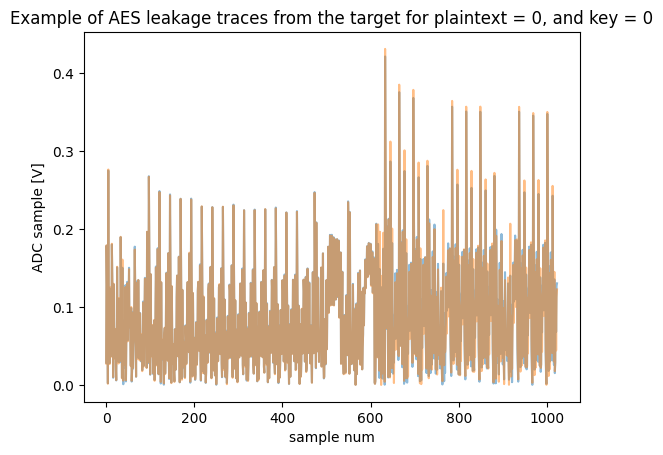

In [ ]:
def get_average_trace_for_key(key: bytes, trace_num: int) -> np.ndarray:
    traces = []

    for i in range(trace_num):
        _, trace = handler.encrypt_and_capture_trace(
            b'\x00' * CWHandler.AES_BLOCK_SIZE_BYTES, key
        )
        traces.append(trace)


    res = np.array([np.float64(0)] * ADC_SAMPLE_NUM)
    for trace in traces:
        res += trace
    
    return np.abs(res / trace_num)

SAMPLE_SIZE = 10
avg_trace_key_0s = get_average_trace_for_key(b'\x00' * CWHandler.AES_BLOCK_SIZE_BYTES, SAMPLE_SIZE)
avg_trace_key_1s = get_average_trace_for_key(b'\xFF' * CWHandler.AES_BLOCK_SIZE_BYTES, SAMPLE_SIZE)

plt.plot(avg_trace_key_0s, alpha=0.5)
plt.plot(avg_trace_key_1s, alpha=0.5)
plt.xlabel("sample num")
plt.ylabel("ADC sample [V]")
plt.title(
    "Example of AES leakage traces from the target for plaintext = 0, and key = 0"
)

Deleting `handler` - disconnects us from the ChipWhisperer

In [46]:
del handler